# Modelo de Predicción de Sentimiento Financiero con FinBERT

Este proyecto desarrolla un modelo de predicción de sentimiento aplicado a noticias financieras en inglés, con el objetivo de clasificar automáticamente el tono de cada artículo en una escala continua de −1 a +1, donde los valores negativos representan sentimiento bajista (bearish) y los positivos sentimiento alcista (bullish).

El modelo se basa en FinBERT (Financial BERT), un modelo transformer preentrenado específicamente sobre texto financiero (noticias de mercados, informes de analistas y documentos de la SEC) que proporciona una comprensión del lenguaje financiero considerablemente superior a la de modelos de propósito general como BERT estándar.

Los detalles del modelo están descritos en el paper FinBERT: Financial Sentiment Analysis with Pre-trained Language Models de Dofu Araci disponible en https://arxiv.org/abs/1908.10063

Sobre este backbone preentrenado se añade una cabeza de regresión propia, entrenada con un corpus de aproximadamente 67.000 artículos de noticias financieras etiquetados con puntuaciones de sentimiento (sobre un total original de más de 180.000). El proceso de entrenamiento incorpora técnicas de remuestreo estratificado para corregir el desequilibrio natural de las clases (las noticias financieras tienden a ser predominantemente positivas) así como una función de pérdida asimétrica que penaliza especialmente los errores de dirección, es decir, predecir sentimiento alcista en artículos inequívocamente bajistas.

El resultado es un modelo capaz de asignar una puntuación de sentimiento continua a cualquier artículo financiero y derivar automáticamente su categoría cualitativa: *Bearish*, *Somewhat Bearish*, *Neutral*, *Somewhat Bullish* o *Bullish*.

# Análisis Exploratorio de Datos — Noticias Financieras

Esta sección del notebook realiza un análisis exploratorio completo del corpus de noticias financieras etiquetadas con puntuaciones de sentimiento. El análisis progresa desde estadísticas descriptivas básicas hasta técnicas de agrupamiento (*clustering*) no supervisado, con el objetivo de comprender la estructura del dataset y fundamentar las decisiones de diseño del modelo predictivo posterior.

**Estructura del análisis:**
1. Carga e inspección inicial
2. Análisis descriptivo: variables numéricas y categóricas
3. Análisis de texto: longitud, vocabulario, términos frecuentes
4. Análisis de agrupamiento (*clustering*)
5. Conclusiones

Comenzamos por importar pandas e instalar las dependencias necesarias para poder leer archivos de tipo parquet, que es el formato en el que se encuentran nuestros datos. El archivo parquet es generado como parte del flujo de scraping, cuyo código está disponible como parte de este TFM.

In [ ]:
# !pip install pandas numpy matplotlib seaborn scikit-learn umap-learn \
#              wordcloud nltk pyarrow fastparquet --quiet

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import string

# Texto
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Reducción dimensional para visualización
from sklearn.manifold import TSNE
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP no disponible — se usará t-SNE para visualización")

# WordCloud
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False

# Configuración de visualización
plt.rcParams['figure.dpi']       = 120
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

PALETTE = ['#1D9E75','#534AB7','#D85A30','#F0A500','#888780']
sns.set_palette(PALETTE)

Mounted at /content/gdrive


In [ ]:
PARQUET_PATH = '/content/gdrive/MyDrive/parquet/news_2018_2026.parquet'
SCORE_COL    = 'overall_sentiment_score'
LABEL_COL    = 'overall_sentiment_label'
TITLE_COL    = 'title'
SUMMARY_COL  = 'summary'
SOURCE_COL   = 'source'
CATEGORY_COL = 'category'

BUCKET_ORDER = ['Bearish', 'Somewhat-Bearish', 'Neutral', 'Somewhat-Bullish', 'Bullish']
BUCKET_COLORS = {
    'Bearish':           '#D85A30',
    'Somewhat-Bearish':  '#F0A500',
    'Neutral':           '#888780',
    'Somewhat-Bullish':  '#5DCAA5',
    'Bullish':           '#1D9E75',
}

## 1. Carga inicial de datos

In [ ]:
df = pd.read_parquet(PARQUET_PATH)

print(f"Dimensiones del dataset : {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nColumnas disponibles:")
for col in df.columns:
    print(f"  {col:<35} dtype: {df[col].dtype}")

Dimensiones del dataset : 189,286 filas × 7 columnas

Columnas disponibles:
  title                               dtype: object
  time_published                      dtype: object
  summary                             dtype: object
  source                              dtype: object
  category_within_source              dtype: object
  overall_sentiment_score             dtype: float64
  overall_sentiment_label             dtype: object


Las columnas de nuestro dataset representan lo siguente:

- title: es el título de la noticia tal cual fue publicado.
- time_published: la fecha de publicación.
- summary: un resumen del texto principal del artículo.
- source: la fuente o medio del que proviene el artículo (por ejemplo, MarketWatch, Reuters, Bloomberg.com, etc).
- category_within_source: la categoría es siempre la misma y no es de importancia para el análisis; esta fue recopilada haciendo el scraping.
- overall_sentiment_score: un puntaje de -1 a 1 teórico que representa el sentimiento del texto (de negativo a positivo).
- overall_sentiment_label: las etiquetas de sentimiento en que se traducen los puntajes.

Exploramos las primeras filas para ver el contenido de las columnas.

In [ ]:
df.head(5)

,title,time_published,summary,source,category_within_source,overall_sentiment_score,overall_sentiment_label
0,Why Icahn Enterprises Stock Is Moving Higher Today,20260228T235326,"Icahn Enterprises' stock (IEP) rose after reporting a strong financial performance in its fourth quarter. The company surpassed analyst revenue estimates and significantly improved its profitability, along with announcing a quarterly distribution of 50 cents per depositary unit.",Sahm,General,0.442283,Bullish
1,IGC Pharma Files Utility Patent Applications Covering AI-Based Data Harmonization Architecture Supporting Alzheimer's Research,20260228T235313,"IGC Pharma has filed utility patent applications for its internally developed AI-based data harmonization system, the Agentic Harmonization Assistant (AHA). AHA aims to standardize diverse Alzheimer's disease datasets to facilitate cross-cohort analysis, clinical research, and AI model development. The company believes this scalable dataset harmonization infrastructure will be crucial as AI-driven analysis expands in Alzheimer's research.",Newswire,General,0.438313,Bullish
2,"MAT Financials: Income Statement, Balance Sheet & Cash Flow",20260228T235308,"This article provides a comprehensive financial overview of Mattel Inc (MAT), detailing its income statement, balance sheet, cash flow statement, and key financial ratios up to fiscal year 2025. It highlights the company's financial health signals across profitability, growth, leverage, liquidity, cash flow, and returns, alongside annual and quarterly metrics derived from SEC filings. The analysis also includes expert scores like Altman Z-Score and Piotroski F-Score for assessing financial risk and strength.",Stock Titan,General,-0.095885,Neutral
3,Landstar Selects SkyBitz for Trailer Tracking,20260228T235302,"Landstar System Inc., a transportation capacity provider, has chosen SkyBitz's GLS Services for trailer tracking. Landstar plans to install SkyBitz Mobile Terminals on existing trailers and new units being built in the first half of 2003. SkyBitz's GLS is a satellite-based tracking and monitoring service that offers improvements over GPS technology in terms of cost, coverage, power consumption, and ease of installation, designed specifically for the transportation industry.",Heavy Duty Trucking,General,0.402925,Bullish
4,"Revenue per share of K Wave Media, Ltd. – NASDAQ:KWMWW",20260228T235300,"This article provides financial information for K Wave Media, Ltd. (NASDAQ: KWMWW), specifically focusing on its revenue per share. It appears to be a stub or a section from a larger financial data platform like TradingView, indicating that the detailed revenue per share values were not loaded in this snippet. The content highlights the stock ticker and links to financial data resources.",TradingView,General,0.020864,Neutral


A continuación exploramos los valores nulos y la cobertura de cada columna, es base al scraping que hemos hecho, estos valores deberían ser mínimos.

In [ ]:
null_report = pd.DataFrame({
    'nulos':      df.isnull().sum(),
    'pct_nulos':  (df.isnull().sum() / len(df) * 100).round(2),
    'únicos':     df.nunique(),
    'cobertura':  ((1 - df.isnull().mean()) * 100).round(2)
})

print("Reporte de calidad por columna:")
print(null_report.to_string())

# Alerta si hay columnas críticas con nulos
critical = [SCORE_COL, LABEL_COL, TITLE_COL]
for col in critical:
    if col in df.columns and df[col].isnull().sum() > 0:
        print(f"\n⚠️  Columna crítica '{col}' tiene {df[col].isnull().sum():,} nulos")

Reporte de calidad por columna:
                         nulos  pct_nulos  únicos  cobertura
title                        0       0.00  189286     100.00
time_published               0       0.00  166418     100.00
summary                    108       0.06  189178      99.94
source                       0       0.00   13283     100.00
category_within_source       0       0.00       1     100.00
overall_sentiment_score      0       0.00  162294     100.00
overall_sentiment_label      0       0.00       5     100.00


## 2. Análisis descriptivo

En esta sección vamos a hacer una análisis descriptivo de las variables para poder entender mejor los principales estadísticos.

In [ ]:
print("Estadísticas descriptivas — puntuación de sentimiento:")
print(df[SCORE_COL].describe().round(4).to_string())

# Percentiles adicionales
pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
print("\nPercentiles adicionales:")
for p in pcts:
    print(f"  P{p:>2} : {df[SCORE_COL].quantile(p/100):>8.4f}")

Estadísticas descriptivas — puntuación de sentimiento:
count    189286.0000
mean          0.1927
std           0.2959
min          -0.9496
25%           0.0295
50%           0.2477
75%           0.4169
max           1.0000

Percentiles adicionales:
  P 1 :  -0.6436
  P 5 :  -0.4056
  P10 :  -0.2329
  P25 :   0.0295
  P50 :   0.2477
  P75 :   0.4169
  P90 :   0.4779
  P95 :   0.5332
  P99 :   0.8337


La primera conclusión que podemos obtener de nuestro dataset es que el rango de los valores objetivo va de -0.94 a 1.00, con lo cual no tenemos un ejemplo de una noticia que llegue al extremo -1. Esto nos indica una tendencia a noticias más bien positivas, como se corrobora el hecho de que la media aritmética sea de 0.1927.

A partir de estas observaciones, construimos una serie de gráficos para entender mejor la distribución de las variables categóricas. Esto nos va a permitir informarnos mejors sobre la forma en la que se agrupan los puntajes en nuestro dataset.

[]

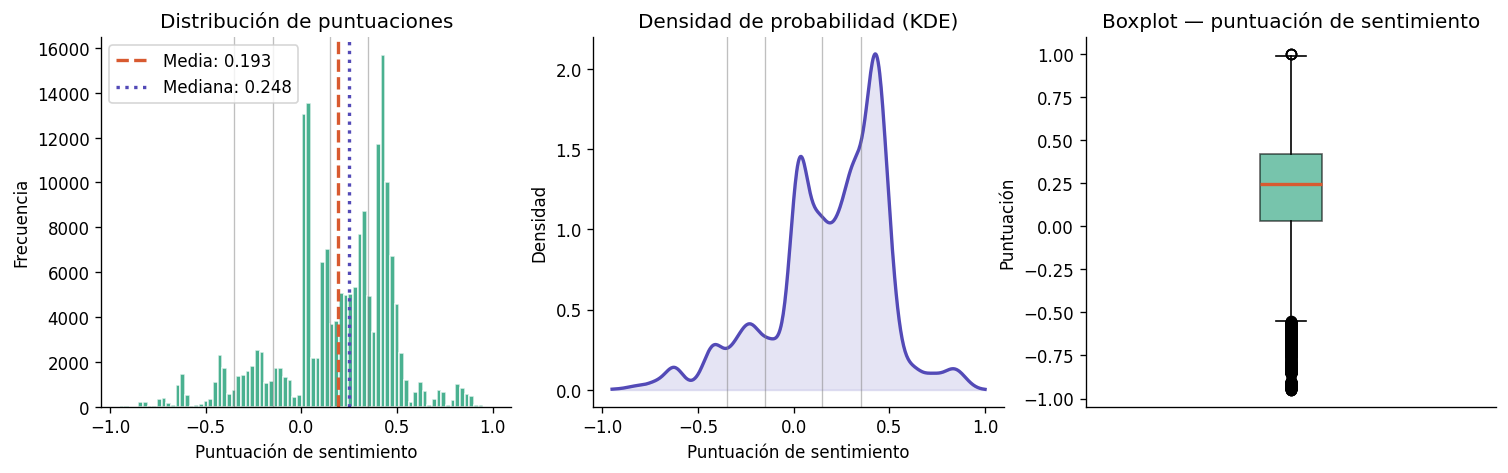

In [ ]:
from scipy.stats import gaussian_kde as gkde

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scores_clean = df[SCORE_COL].dropna()

# --- Histograma ---
axes[0].hist(scores_clean, bins=80, color='#1D9E75', alpha=0.8, edgecolor='white')
axes[0].axvline(scores_clean.mean(),   color='#D85A30', lw=2, ls='--',
                label=f'Media: {scores_clean.mean():.3f}')
axes[0].axvline(scores_clean.median(), color='#534AB7', lw=2, ls=':',
                label=f'Mediana: {scores_clean.median():.3f}')
axes[0].set_title('Distribución de puntuaciones')
axes[0].set_xlabel('Puntuación de sentimiento')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
for thresh in [-0.35, -0.15, 0.15, 0.35]:
    axes[0].axvline(thresh, color='gray', lw=0.8, ls='-', alpha=0.5)

# --- KDE — calculado manualmente con scipy, sin llamadas a plot.kde() ocultas ---
x_grid   = np.linspace(scores_clean.min(), scores_clean.max(), 500)
kde_vals  = gkde(scores_clean, bw_method=0.15)(x_grid)

axes[1].plot(x_grid, kde_vals, color='#534AB7', lw=2)
axes[1].fill_between(x_grid, kde_vals, alpha=0.15, color='#534AB7')
axes[1].set_title('Densidad de probabilidad (KDE)')
axes[1].set_xlabel('Puntuación de sentimiento')
axes[1].set_ylabel('Densidad')
for thresh in [-0.35, -0.15, 0.15, 0.35]:
    axes[1].axvline(thresh, color='gray', lw=0.8, alpha=0.5)

# --- Boxplot ---
axes[2].boxplot(scores_clean, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#1D9E75', alpha=0.6),
                medianprops=dict(color='#D85A30', lw=2))
axes[2].set_title('Boxplot — puntuación de sentimiento')
axes[2].set_ylabel('Puntuación')
axes[2].set_xticks([])

Los gráficos que acabamos de realizar confirman nuestra observación de que, en general, tenemos más artículos con sentimientos positivos que negativos. Vemos claramente que tenemos más artículos por encima de la media que por debajo, e incluso la media es positiva. El gráfico de densidad de probabilidad es más claro en este sentido, ya que suaviza las curvas y nos confirman la predominancia de artículos neutrales cercanos al cero y un pico alrededor del 0.5.

También puede ser interesante analizar los datos según las fuentes de las que provienen. Para esto realizamos los correspondientes gráficos de barras.


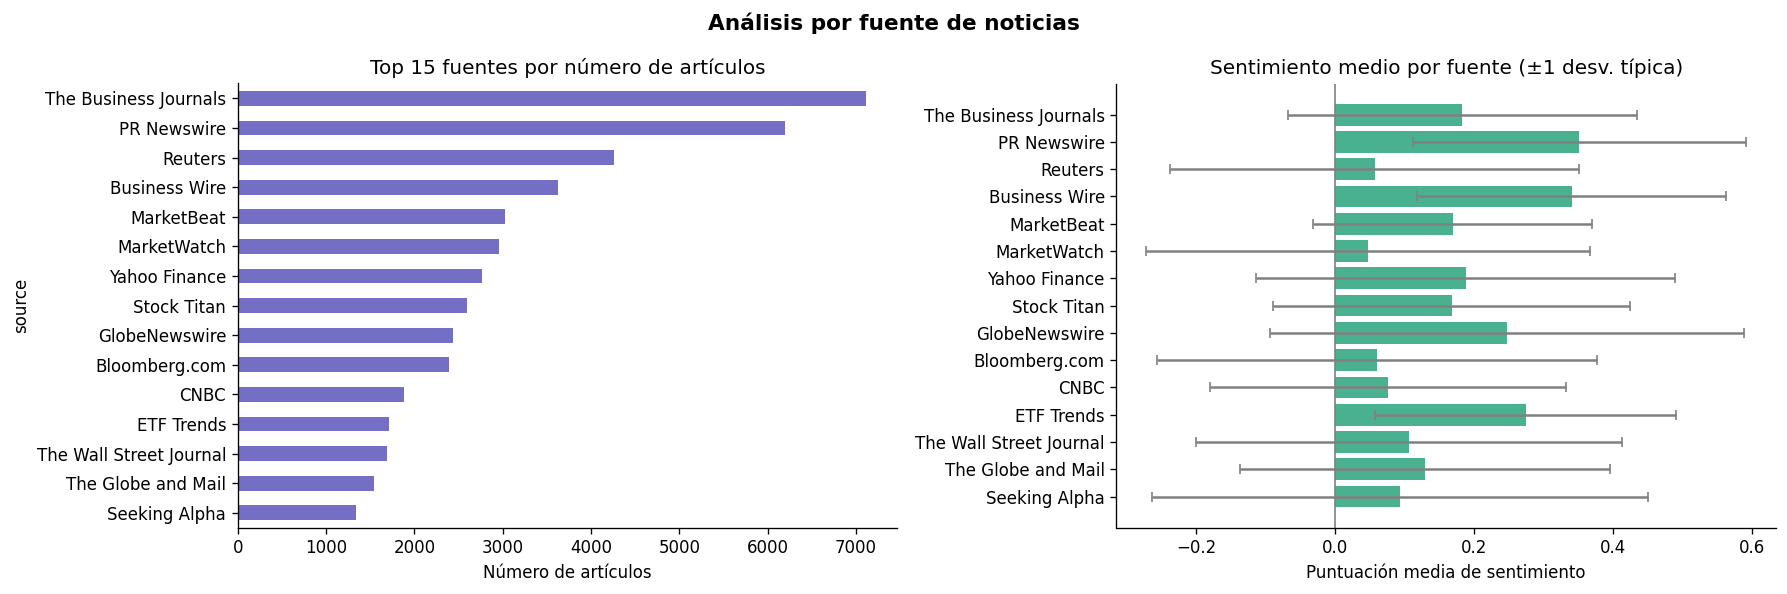

In [ ]:
if SOURCE_COL in df.columns:
    top_sources = df[SOURCE_COL].value_counts().head(15)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Top fuentes por volumen
    top_sources.plot.barh(ax=axes[0], color='#534AB7', alpha=0.8)
    axes[0].set_title('Top 15 fuentes por número de artículos')
    axes[0].set_xlabel('Número de artículos')
    axes[0].invert_yaxis()

    # Sentimiento medio por fuente
    source_sentiment = (
        df[df[SOURCE_COL].isin(top_sources.index)]
        .groupby(SOURCE_COL)[SCORE_COL]
        .agg(['mean', 'std', 'count'])
        .reindex(top_sources.index)
    )
    colors_bar = ['#D85A30' if m < 0 else '#1D9E75' for m in source_sentiment['mean']]
    axes[1].barh(source_sentiment.index, source_sentiment['mean'],
                 xerr=source_sentiment['std'], color=colors_bar, alpha=0.8,
                 error_kw=dict(ecolor='gray', capsize=3))
    axes[1].axvline(0, color='gray', lw=1)
    axes[1].set_title('Sentimiento medio por fuente (±1 desv. típica)')
    axes[1].set_xlabel('Puntuación media de sentimiento')
    axes[1].invert_yaxis()

    plt.suptitle('Análisis por fuente de noticias', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('analisis_fuentes.png', dpi=120, bbox_inches='tight')
    plt.show()

Podemos ver que las fuentes de los artículos están dominadas en su mayoría por unas cuantas publicaciones reconocidas. En el gráfico de sentimiento medio por fuente podemos apreciar que The Business Journal y PR Newswire, que tienen los dos primeros puestos, publican noticias predominantemente positivas, con una media bien entrada en territorio de sentimiento alcista. Sin embargo, también podemos ver publicaciones que tienen su rango intercuartil con publicaciones de sentimiento negativo. Esto resulta interesante además para comprender los medios y las noticias que leemos: algunos medios tienen tendencias a noticias positivas (por ejemplo, PR Newswire es un repositorio de press releases de empresas y naturalmente tenderán a ser positivas), mientras que otros medios tienen un rango más amplio (por ejemplo, MarketWatch es una plataforma que se usa para hacer investigación de inversiones y también contiene muchas noticias negativas).

Por último, comentar que no es necesario hacer el análisis por categoría, ya que, como se ha mostrado en un apartado anterior, solo existe una categoría.

## 3. Análisis del Texto

En esta sección nos ocuparemos de ver si hay características distintivas en el texto que debamos tener en cuenta a la hora de construir nuestro modelo predictivo. Analizaremos la longitud del texto, las palabras clave y el agrupamiento.

En esta sección realizamos una construcción del campo de texto combinado y análisis de longitud. La idea es generar nuevas columnas con la longitud de caracteres y de palabras del texto y del título.

In [ ]:
df['text'] = df[TITLE_COL].fillna('') + ' ' + df[SUMMARY_COL].fillna('')
df['text'] = df['text'].str.strip()

# Longitud en caracteres y palabras
df['len_chars']  = df['text'].str.len()
df['len_words']  = df['text'].str.split().str.len()
df['len_title']  = df[TITLE_COL].fillna('').str.split().str.len()
df['len_summary']= df[SUMMARY_COL].fillna('').str.split().str.len()

print("Estadísticas de longitud de texto (palabras):")
print(df[['len_title', 'len_summary', 'len_words']].describe().round(1).to_string())

Estadísticas de longitud de texto (palabras):
       len_title  len_summary  len_words
count   189286.0     189286.0   189286.0
mean        10.7         67.4       78.0
std          4.5         12.4       13.6
min          1.0          0.0        2.0
25%          8.0         60.0       70.0
50%         10.0         68.0       78.0
75%         13.0         75.0       87.0
max       1072.0        133.0     1149.0


Ahora que tenemos las longitudes, podemos analizar si los diferentes sentimientos suelen traducirse en una mayor o menor longitud de texto.

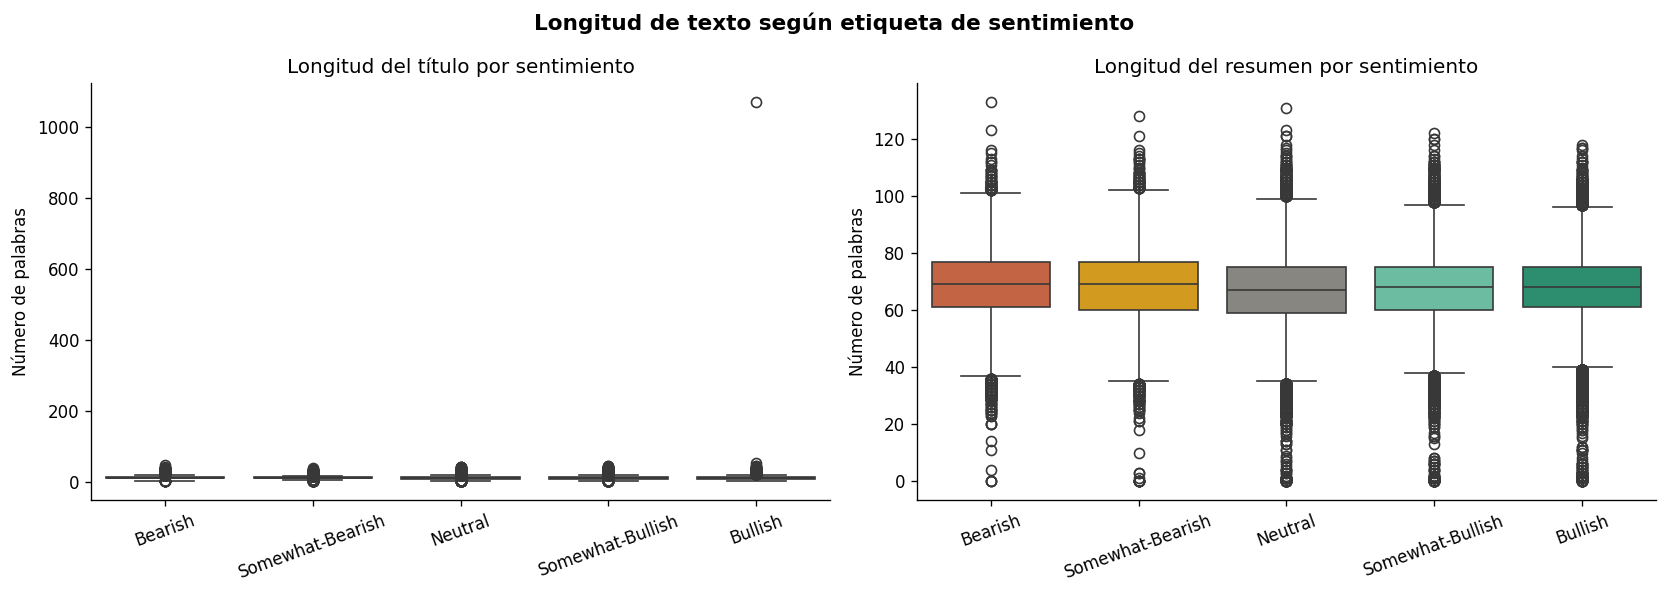


Test Kruskal-Wallis (longitud vs etiqueta): H=601.44, p=0.0000
→ Diferencias estadísticamente significativas entre grupos (p < 0.05)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Longitud de título por bucket
df_valid = df[df[LABEL_COL].isin(BUCKET_ORDER)]
sns.boxplot(
    data=df_valid, x=LABEL_COL, y='len_title',
    order=BUCKET_ORDER, ax=axes[0],
    palette=[BUCKET_COLORS[b] for b in BUCKET_ORDER]
)
axes[0].set_title('Longitud del título por sentimiento')
axes[0].set_xlabel('')
axes[0].set_ylabel('Número de palabras')
axes[0].tick_params(axis='x', rotation=20)

# Longitud de resumen por bucket
sns.boxplot(
    data=df_valid, x=LABEL_COL, y='len_summary',
    order=BUCKET_ORDER, ax=axes[1],
    palette=[BUCKET_COLORS[b] for b in BUCKET_ORDER]
)
axes[1].set_title('Longitud del resumen por sentimiento')
axes[1].set_xlabel('')
axes[1].set_ylabel('Número de palabras')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Longitud de texto según etiqueta de sentimiento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('longitud_por_sentimiento.png', dpi=120, bbox_inches='tight')
plt.show()

# Test estadístico: ¿difieren las longitudes entre grupos?
from scipy.stats import kruskal
groups = [df_valid[df_valid[LABEL_COL] == b]['len_words'].dropna() for b in BUCKET_ORDER]
stat, p = kruskal(*groups)
print(f"\nTest Kruskal-Wallis (longitud vs etiqueta): H={stat:.2f}, p={p:.4f}")
if p < 0.05:
    print("→ Diferencias estadísticamente significativas entre grupos (p < 0.05)")
else:
    print("→ No hay diferencias significativas en longitud entre grupos")

Observamos que realmente no hay mucha diferencia y la longitud del texto no es un factor a tener en cuenta para nuestro análisis.

Me ha parecido interesante también analizar las palabras más frecuentes de los sementos Bearish y Bullish. Esto es importante porque idealmente nos gustaría que hubiesen palabras clave que apuntan inequívocamente a un sentimiento en particular.

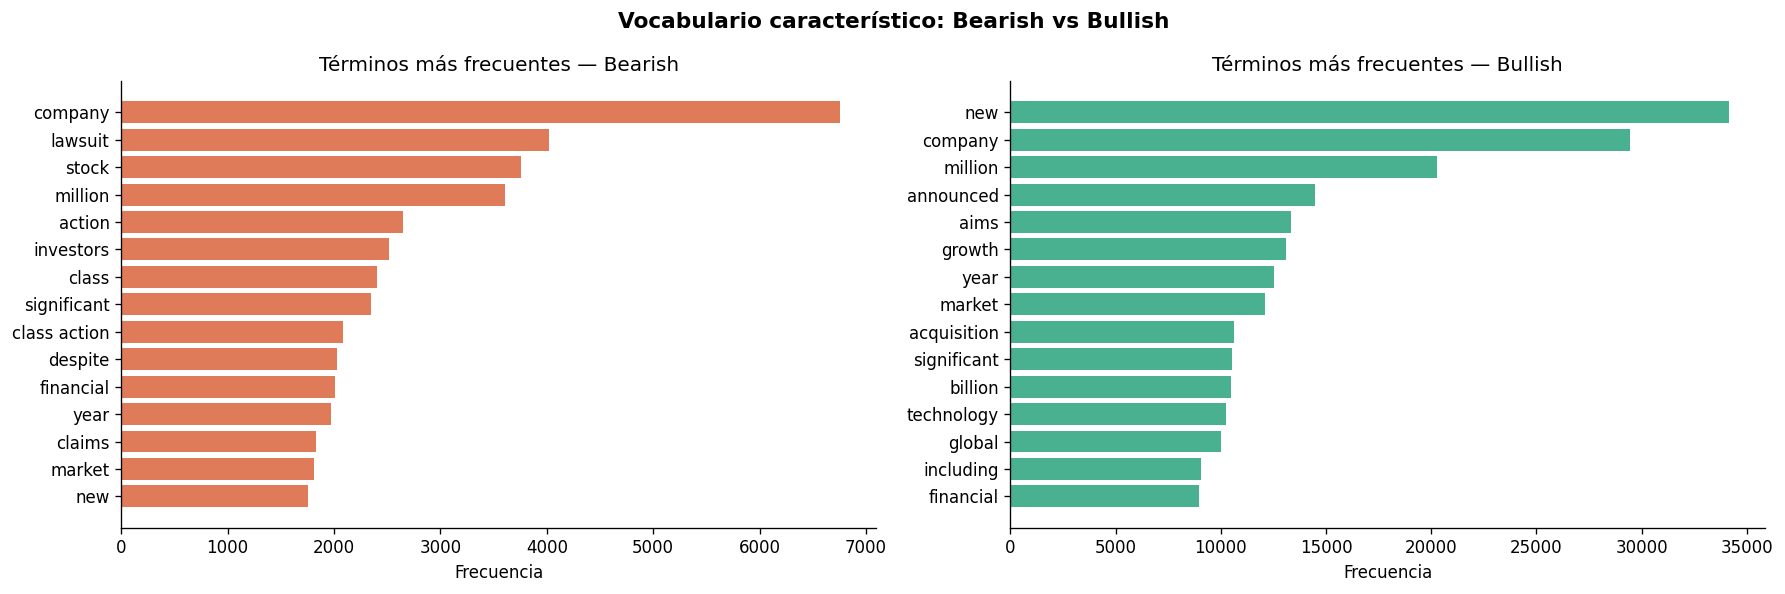

In [ ]:
def get_top_terms(texts, n=25, ngram=(1,2)):
    """Extrae los n términos más frecuentes de una lista de textos."""
    vec = CountVectorizer(
        ngram_range=ngram,
        stop_words='english',
        max_features=5000,
        token_pattern=r'\b[a-zA-Z][a-zA-Z]+\b'
    )
    X = vec.fit_transform(texts)
    freqs = X.sum(axis=0).A1
    terms = vec.get_feature_names_out()
    top_idx = freqs.argsort()[::-1][:n]
    return [(terms[i], freqs[i]) for i in top_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, bucket in zip(axes, ['Bearish', 'Bullish']):
    texts = df[df[LABEL_COL] == bucket]['text'].dropna().tolist()
    terms = get_top_terms(texts, n=15)
    words, counts = zip(*terms)
    color = BUCKET_COLORS[bucket]
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.8)
    ax.set_title(f'Términos más frecuentes — {bucket}')
    ax.set_xlabel('Frecuencia')

plt.suptitle('Vocabulario característico: Bearish vs Bullish', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('terminos_frecuentes.png', dpi=120, bbox_inches='tight')
plt.show()

Vemos que sí hay palabras como "lawsuit" (juicio, demanda) o "action" (también demanda o pleito legal) que remiten a noticias negativas para una empresa. Por otro lado, palabras como "growth", "announced" y "acquisition" suelen remitir a artículos clasificados como positivos. También es muy importante tener en cuenta que hay una serie de palabras que aparecen con mucha frecuenta en los dos grupos: "company", "million", "year", "significant", etc. Seguramente estas palabras no aporten tanto valor por sí mismas al clasificador y hay que tener en cuenta que pueden perjudicar el desempeño de la red neuronal.

Realizamos una nube de palabras de los dos sentimientos analizados más arriba.

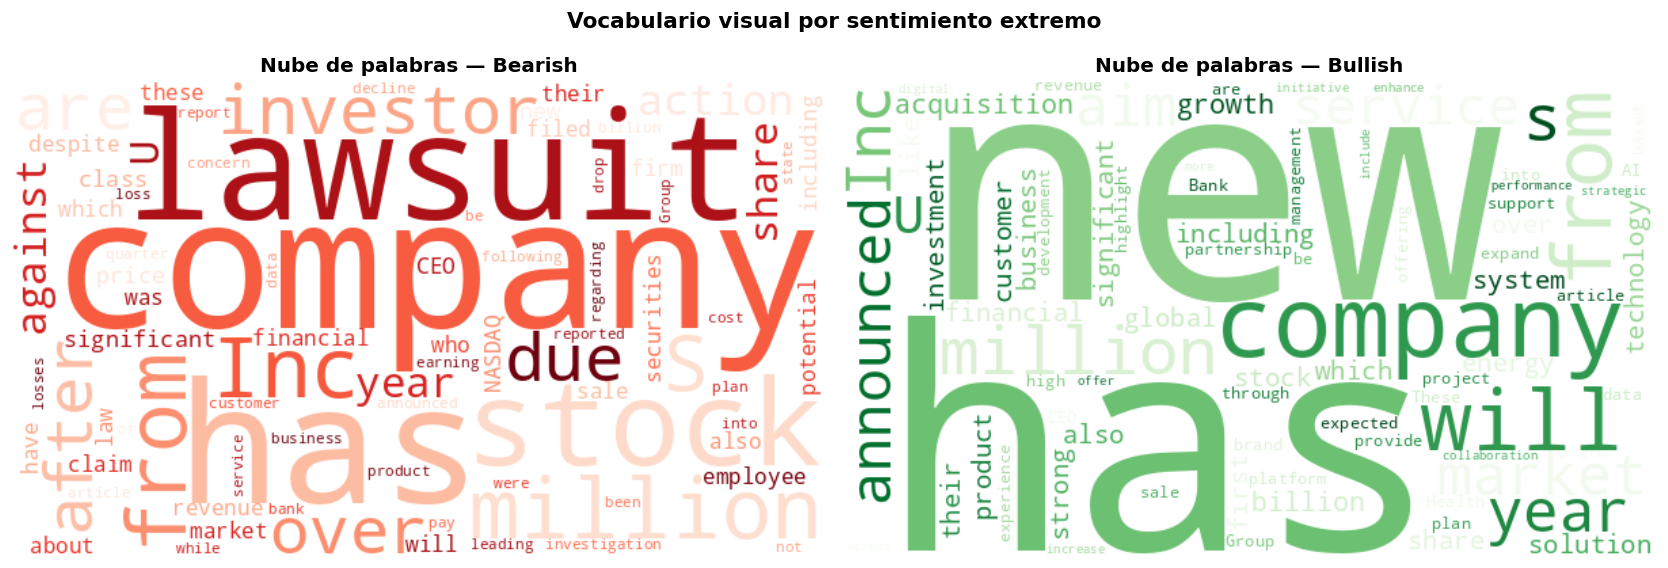

In [ ]:
if WORDCLOUD_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, bucket, cmap in zip(axes,
                                 ['Bearish', 'Bullish'],
                                 ['Reds', 'Greens']):
        texts = ' '.join(df[df[LABEL_COL] == bucket]['text'].dropna().sample(
            min(3000, len(df[df[LABEL_COL] == bucket])), random_state=42
        ).tolist())

        wc = WordCloud(
            width=600, height=350,
            background_color='white',
            colormap=cmap,
            stopwords=set(['the','a','an','in','of','to','and','for','is',
                          'that','this','as','its','it','on','at','by','with']),
            max_words=80,
            collocations=False
        ).generate(texts)

        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'Nube de palabras — {bucket}', fontweight='bold')

    plt.suptitle('Vocabulario visual por sentimiento extremo', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('wordcloud_sentimiento.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print("WordCloud no disponible. Instalar con: pip install wordcloud")

## 4. Análisis del agrupamiento (clustering)

A continuación, nos proponemos realizar un agrupamiento de nuestras noticias para intentar encontrar detalles interesantes.

Comenzamos haciendo una vectorización a partir de un muestreo estratificado. La vectorización TF-IDF transforma cada noticia en una representación numérica según la importancia de sus palabras y combinaciones frecuentes (unigramas y bigramas). Esto permite medir similitud entre textos y aplicar clustering para agrupar noticias con temáticas o patrones de contenido similares.

In [ ]:
SAMPLE_SIZE = 10000   # muestra para clustering — aumentar si hay suficiente RAM

# Muestra estratificada por etiqueta
df_sample = (
    df[df[LABEL_COL].isin(BUCKET_ORDER)]
    .groupby(LABEL_COL, group_keys=False)
    .apply(lambda x: x.sample(
        min(len(x), SAMPLE_SIZE // len(BUCKET_ORDER)),
        random_state=42
    ))
    .reset_index(drop=True)
)

print(f"Muestra para clustering: {len(df_sample):,} artículos")
print(df_sample[LABEL_COL].value_counts().to_string())

# Vectorización TF-IDF
print("\nVectorizando textos con TF-IDF...")
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=3,
    token_pattern=r'\b[a-zA-Z][a-zA-Z]+\b'
)
X_tfidf = vectorizer.fit_transform(df_sample['text'].fillna(''))
print(f"Matriz TF-IDF: {X_tfidf.shape[0]:,} documentos × {X_tfidf.shape[1]:,} términos")

Muestra para clustering: 10,000 artículos
overall_sentiment_label
Bearish             2000
Bullish             2000
Neutral             2000
Somewhat-Bearish    2000
Somewhat-Bullish    2000

Vectorizando textos con TF-IDF...
Matriz TF-IDF: 10,000 documentos × 5,000 términos


La reducción dimensional con TruncatedSVD (LSA) convierte la matriz TF-IDF, muy grande y dispersa, en un espacio de menor dimensión que conserva la mayor parte de la información relevante. A diferencia de PCA, SVD funciona correctamente con matrices dispersas sin necesidad de convertirlas. Esto permite reducir ruido, mejorar la eficiencia computacional y facilitar el clustering al capturar relaciones semánticas latentes entre palabras y documentos. Después, la normalización prepara los vectores para clustering esférico, mejorando la comparación de similitud entre noticias mediante distancia angular o coseno.

Reduciendo a 100 dimensiones con SVD (LSA)...
Varianza explicada con 100 componentes: 16.8%


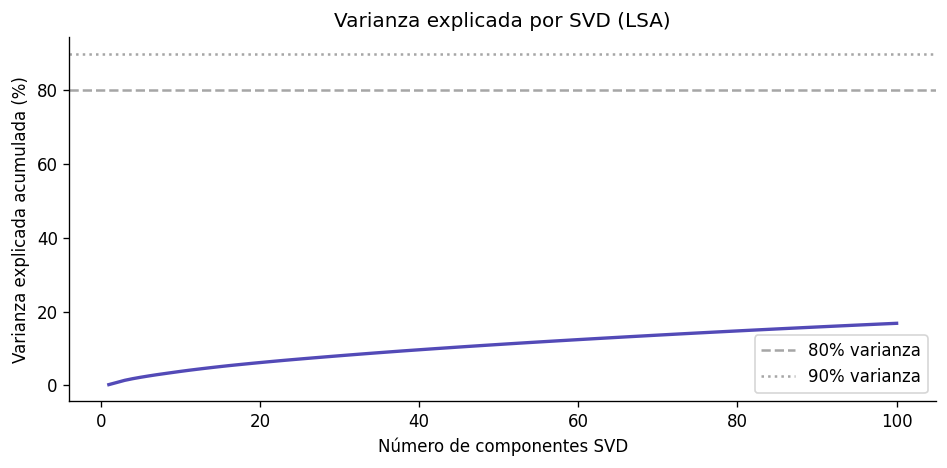

In [ ]:
N_COMPONENTS = 100   # dimensiones latentes para clustering

print(f"Reduciendo a {N_COMPONENTS} dimensiones con SVD (LSA)...")
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

explained_var = svd.explained_variance_ratio_.cumsum()
print(f"Varianza explicada con {N_COMPONENTS} componentes: {explained_var[-1]*100:.1f}%")

# Normalizar para clustering esférico
from sklearn.preprocessing import normalize
X_svd_norm = normalize(X_svd)

# Curva de varianza explicada
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(explained_var)+1), explained_var * 100, color='#534AB7', lw=2)
ax.axhline(80, color='gray', ls='--', alpha=0.7, label='80% varianza')
ax.axhline(90, color='gray', ls=':', alpha=0.7, label='90% varianza')
ax.set_xlabel('Número de componentes SVD')
ax.set_ylabel('Varianza explicada acumulada (%)')
ax.set_title('Varianza explicada por SVD (LSA)')
ax.legend()
plt.tight_layout()
plt.savefig('varianza_svd.png', dpi=120, bbox_inches='tight')
plt.show()

Utilizamos el método del codo para determinar el valor K más adecuado para nuestro agrupado (K-Means).

Calculando inercia para diferentes valores de K...
  K= 2  inercia=8847.2  silhouette=0.0482
  K= 3  inercia=8675.8  silhouette=0.0560
  K= 4  inercia=8525.4  silhouette=0.0612
  K= 5  inercia=8394.2  silhouette=0.0653
  K= 6  inercia=8272.9  silhouette=0.0599
  K= 7  inercia=8165.2  silhouette=0.0724
  K= 8  inercia=8080.6  silhouette=0.0719
  K= 9  inercia=7958.5  silhouette=0.0847
  K=10  inercia=7872.2  silhouette=0.0871
  K=11  inercia=7778.2  silhouette=0.0969


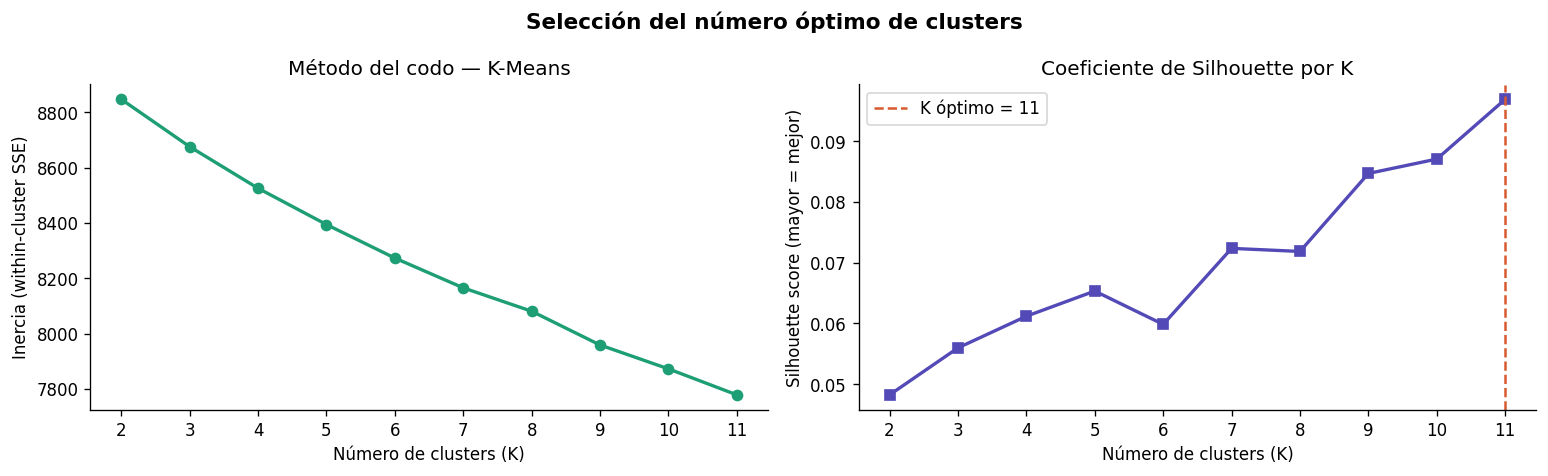


K óptimo según Silhouette: 11


In [ ]:
print("Calculando inercia para diferentes valores de K...")
K_range    = range(2, 12)
inertias   = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=200)
    labels_km = km.fit_predict(X_svd_norm)
    inertias.append(km.inertia_)

    # Silhouette en submuestra (costoso computacionalmente)
    idx = np.random.choice(len(X_svd_norm), min(2000, len(X_svd_norm)), replace=False)
    sil = silhouette_score(X_svd_norm[idx], labels_km[idx], metric='cosine')
    sil_scores.append(sil)
    print(f"  K={k:>2}  inercia={km.inertia_:.1f}  silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertias, 'o-', color='#1D9E75', lw=2)
axes[0].set_title('Método del codo — K-Means')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia (within-cluster SSE)')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, sil_scores, 's-', color='#534AB7', lw=2)
best_k = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(best_k, color='#D85A30', ls='--', label=f'K óptimo = {best_k}')
axes[1].set_title('Coeficiente de Silhouette por K')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette score (mayor = mejor)')
axes[1].set_xticks(list(K_range))
axes[1].legend()

plt.suptitle('Selección del número óptimo de clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('seleccion_k.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\nK óptimo según Silhouette: {best_k}")

El K óptimo sería 11 según la gráfica. Sin embargo, sabemos que tenemos cinco categorías en realidad. Esto nos informa de que los datos que tenemos a mano son muy dispersos y difusos. Vamos a realizar la agrupación con cinco categorías con el fin de compararla con las verdaderas etiquetas. En una versión anterior realicé la agrupación con 11 categorías y en el gráfico se podían apreciar bastante separadas entre sí, los cual es un punto interesante para un clasificador más complejo en el futuro.



In [ ]:
K_FINAL = 5 #best_k   # o ajustar manualmente si el codo sugiere otro valor

print(f"Entrenando K-Means con K={K_FINAL}...")
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10, max_iter=300)
df_sample['cluster'] = kmeans.fit_predict(X_svd_norm)

print(f"\nDistribución de artículos por cluster:")
print(df_sample['cluster'].value_counts().sort_index().to_string())

# Distribución de sentimiento dentro de cada cluster
cluster_stats = (
    df_sample.groupby('cluster')[SCORE_COL]
    .agg(['mean', 'std', 'count'])
    .round(4)
)
cluster_stats.columns = ['Media sentimiento', 'Desv. típica', 'N artículos']
print("\nEstadísticas de sentimiento por cluster:")
print(cluster_stats.to_string())

Entrenando K-Means con K=5...

Distribución de artículos por cluster:
cluster
0     604
1    2400
2    1990
3     816
4    4190

Estadísticas de sentimiento por cluster:
         Media sentimiento  Desv. típica  N artículos
cluster                                              
0                  -0.4077        0.2426          604
1                  -0.0503        0.3399         2400
2                   0.2812        0.2499         1990
3                   0.0994        0.2981          816
4                  -0.0600        0.3610         4190


Utilizamos UMAP para reducir a dos dimensiones.

Reduciendo a 2D con UMAP...
Reducción UMAP completada.


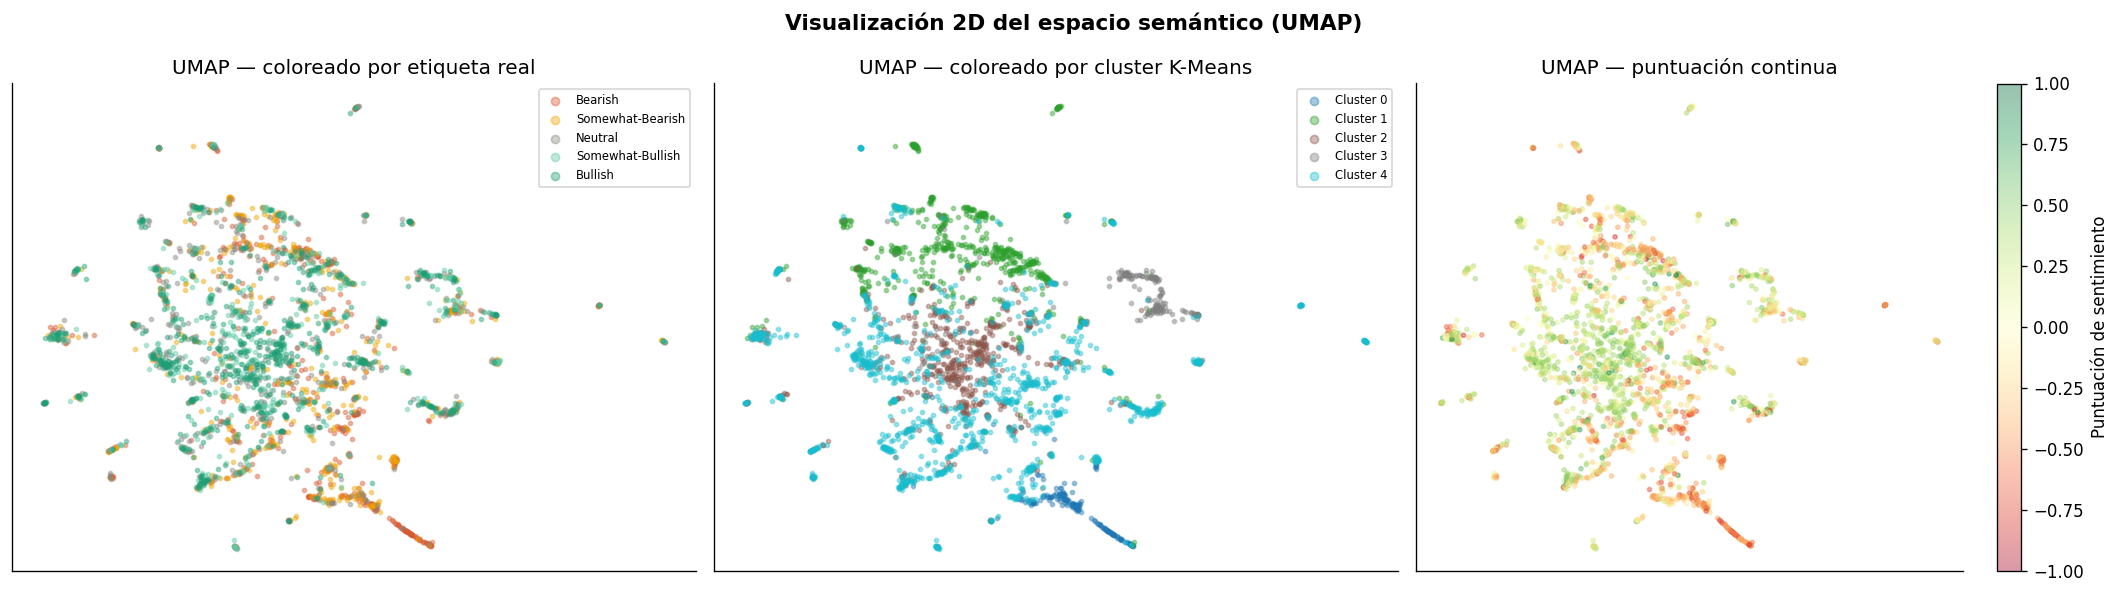

In [ ]:
# Submuestrear para que t-SNE sea rápido
VIZ_SAMPLE = min(3000, len(df_sample))
idx_viz    = np.random.choice(len(df_sample), VIZ_SAMPLE, replace=False)

X_viz      = X_svd_norm[idx_viz]
labels_viz = df_sample[LABEL_COL].iloc[idx_viz].values
cluster_viz= df_sample['cluster'].iloc[idx_viz].values
scores_viz = df_sample[SCORE_COL].iloc[idx_viz].values

if UMAP_AVAILABLE:
    print("Reduciendo a 2D con UMAP...")
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
    X_2d    = reducer.fit_transform(X_viz)
    method_name = 'UMAP'
else:
    print("Reduciendo a 2D con t-SNE (puede tardar 1-2 minutos)...")
    tsne  = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=1000, verbose=0)
    X_2d  = tsne.fit_transform(X_viz)
    method_name = 't-SNE'

print(f"Reducción {method_name} completada.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: coloreado por etiqueta real
for bucket in BUCKET_ORDER:
    mask = labels_viz == bucket
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=BUCKET_COLORS[bucket], label=bucket,
                    alpha=0.4, s=6)
axes[0].set_title(f'{method_name} — coloreado por etiqueta real')
axes[0].legend(markerscale=2, fontsize=7)
axes[0].set_xticks([]); axes[0].set_yticks([])

# Plot 2: coloreado por cluster K-Means
cluster_palette = plt.cm.tab10(np.linspace(0, 1, K_FINAL))
for k in range(K_FINAL):
    mask = cluster_viz == k
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=[cluster_palette[k]], label=f'Cluster {k}',
                    alpha=0.4, s=6)
axes[1].set_title(f'{method_name} — coloreado por cluster K-Means')
axes[1].legend(markerscale=2, fontsize=7)
axes[1].set_xticks([]); axes[1].set_yticks([])

# Plot 3: coloreado por puntuación continua
sc = axes[2].scatter(X_2d[:, 0], X_2d[:, 1],
                     c=scores_viz, cmap='RdYlGn',
                     vmin=-1, vmax=1, alpha=0.4, s=6)
plt.colorbar(sc, ax=axes[2], label='Puntuación de sentimiento')
axes[2].set_title(f'{method_name} — puntuación continua')
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.suptitle(f'Visualización 2D del espacio semántico ({method_name})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'visualizacion_2d_{method_name.lower()}.png', dpi=120, bbox_inches='tight')
plt.show()

Observamos que solo las etiquetas Bearish se ven claramente diferenciadas del resto en el margen inferior, y de hecho agrupadas de manera bastante compacta. El siguiente grupo, Somewhat Bearish, se encuentra hacia la parte inferior, aunque muy solapado con el resto de los grupos. Finalmente, el resto de las etiquetas, Neutral, Somewhat Bullish y Bullish se encuentran muy superpuestas entre sí, tanto en los clústers generados por el modelo, como en la realidad.

Análisis final: ¿qué tan bien coinciden los clusters con las etiquetas de sentimiento?

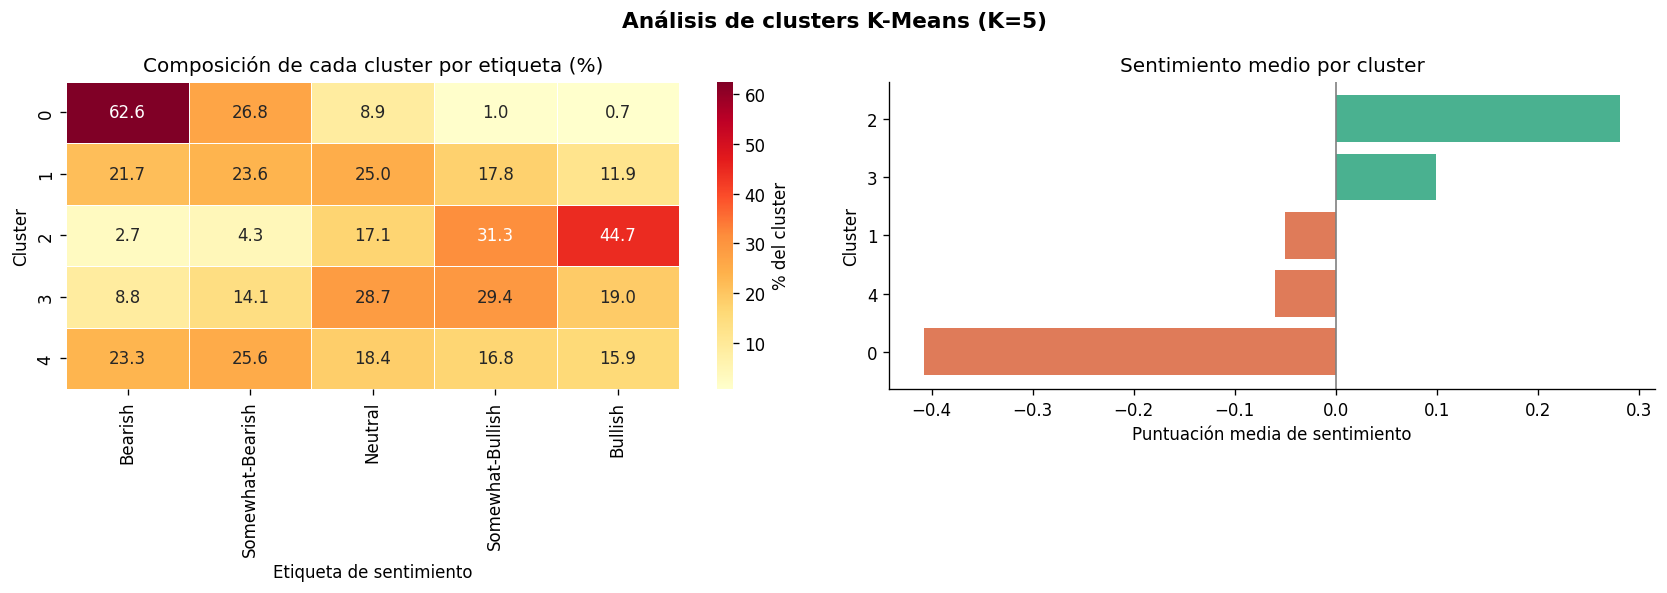

In [ ]:
cluster_label_pivot = (
    df_sample.groupby(['cluster', LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=BUCKET_ORDER, fill_value=0)
)

# Normalizar por fila para ver proporciones
cluster_label_pct = cluster_label_pivot.div(cluster_label_pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de composición
sns.heatmap(
    cluster_label_pct.round(1), ax=axes[0],
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': '% del cluster'}
)
axes[0].set_title('Composición de cada cluster por etiqueta (%)')
axes[0].set_xlabel('Etiqueta de sentimiento')
axes[0].set_ylabel('Cluster')

# Sentimiento medio por cluster (barras)
means = df_sample.groupby('cluster')[SCORE_COL].mean().sort_values()
bar_colors = ['#D85A30' if m < 0 else '#1D9E75' for m in means]
axes[1].barh(means.index.astype(str), means.values, color=bar_colors, alpha=0.8)
axes[1].axvline(0, color='gray', lw=1)
axes[1].set_title('Sentimiento medio por cluster')
axes[1].set_xlabel('Puntuación media de sentimiento')
axes[1].set_ylabel('Cluster')

plt.suptitle(f'Análisis de clusters K-Means (K={K_FINAL})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('composicion_clusters.png', dpi=120, bbox_inches='tight')
plt.show()

Realizamos las métricas de calidad por procedimiento.

Silhouette: cuánto se parece un punto a su cluster vs al más cercano (-1 a 1).

Davies-Bouldin: ratio compacidad/separación (menor = mejor).

In [ ]:
idx_eval  = np.random.choice(len(df_sample), min(3000, len(df_sample)), replace=False)
X_eval    = X_svd_norm[idx_eval]
labels_km = df_sample['cluster'].iloc[idx_eval].values

sil_km = silhouette_score(X_eval, labels_km, metric='cosine')
db_km  = davies_bouldin_score(X_eval, labels_km)

# Comparar con las etiquetas reales como referencia
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels_real_enc = le.fit_transform(df_sample[LABEL_COL].iloc[idx_eval].values)
sil_real = silhouette_score(X_eval, labels_real_enc, metric='cosine')
db_real  = davies_bouldin_score(X_eval, labels_real_enc)

print("Métricas de calidad del clustering:")
print(f"{'':30} {'Silhouette':>12}  {'Davies-Bouldin':>15}")
print("-" * 60)
print(f"{'K-Means (K=' + str(K_FINAL) + ')':30} {sil_km:>12.4f}  {db_km:>15.4f}")
print(f"{'Etiquetas reales (referencia)':30} {sil_real:>12.4f}  {db_real:>15.4f}")
print()
print("Interpretación:")
print("  Silhouette → más cercano a 1 es mejor. Negativo indica clusters solapados.")
print("  Davies-Bouldin → más cercano a 0 es mejor (clusters compactos y separados).")
if sil_km > sil_real:
    print("\n→ Los clusters detectados son más coherentes que las etiquetas predefinidas.")
    print("  Esto sugiere que el espacio semántico contiene estructura adicional más allá del sentimiento.")
else:
    print("\n→ Las etiquetas de sentimiento reflejan bien la estructura del espacio semántico.")
    print("  El modelo supervisado tiene una señal de supervisión de alta calidad.")

Métricas de calidad del clustering:
                                 Silhouette   Davies-Bouldin
------------------------------------------------------------
K-Means (K=11)                       0.0935           3.8960
Etiquetas reales (referencia)       -0.0034          18.5699

Interpretación:
  Silhouette → más cercano a 1 es mejor. Negativo indica clusters solapados.
  Davies-Bouldin → más cercano a 0 es mejor (clusters compactos y separados).

→ Los clusters detectados son más coherentes que las etiquetas predefinidas.
  Esto sugiere que el espacio semántico contiene estructura adicional más allá del sentimiento.


Traducción de puntajes a etiquetas.

In [ ]:
# Check category distribution
print(df["overall_sentiment_label"].value_counts())
print(df["overall_sentiment_label"].value_counts(normalize=True).mul(100).round(1))

# Check float distribution — are scores concentrated in the middle?
print(df["overall_sentiment_score"].describe())
print(f"\nExtreme bearish  (<= -0.35):  {(df['overall_sentiment_score'] <= -0.35).sum():,}")
print(f"Somewhat bearish (-0.35, -0.15): {df['overall_sentiment_score'].between(-0.35,-0.15).sum():,}")
print(f"Neutral          (-0.15, 0.15): {df['overall_sentiment_score'].between(-0.15,0.15).sum():,}")
print(f"Somewhat bullish (0.15, 0.35): {df['overall_sentiment_score'].between(0.15,0.35).sum():,}")
print(f"Bullish          (>= 0.35):   {(df['overall_sentiment_score'] >= 0.35).sum():,}")

overall_sentiment_label
Bullish             65712
Neutral             52488
Somewhat-Bullish    46333
Somewhat-Bearish    13525
Bearish             11228
Name: count, dtype: int64
overall_sentiment_label
Bullish             34.7
Neutral             27.7
Somewhat-Bullish    24.5
Somewhat-Bearish     7.1
Bearish              5.9
Name: proportion, dtype: float64
count    189286.000000
mean          0.192714
std           0.295937
min          -0.949551
25%           0.029522
50%           0.247745
75%           0.416891
max           1.000000
Name: overall_sentiment_score, dtype: float64

Extreme bearish  (<= -0.35):  11,228
Somewhat bearish (-0.35, -0.15): 13,525
Neutral          (-0.15, 0.15): 52,489
Somewhat bullish (0.15, 0.35): 46,334
Bullish          (>= 0.35):   65,712


## 5. Conclusiones

Nuestro conjunto de datos presenta algunas características típicas de los datos que no-sintéticos. Por un lado, tenemos un claro desbalance de observaciones: tenemos muchísimos más ejemplos positivos que negativos; si utilizamos el dataset como tal, el modelo habrá visto muchos más casos positivos y el costará generalizar sobre los casos negativos o bien tenderá a clasificar más noticias como positivas. Por otro lado, a menos que la noticia incluya palabras o frases fuertemente negativas, no es muy fácil diferenciar el espectro del resto de puntajes. En otras palabras, el límite entre neutro, algo positivo y positivo no va a estar muy claro en la mayoría de los casos. En la sección siguiente veremos cómo atacamos estos problemas e intentamos construir un modelo fiable.

# Construcción del modelo predictivo

Utilizaremos TensorFlow y la API de alto nivel Keras para la construcción del modelo. Como se anuncia al comienzo de este notebook, empleamos FinBERT como backbone, ya que ha sido entrenado en millones de artículos financieros.

## 1. Setup

A partir de las conclusiones obtenidas en los apartados anteriores de análisis exploratorio de datos, podemos pasar a construir nuestro modelo predictivo del sentimiento.

Para comenzar, vamos a importar las dependencias necesarias para trabajar con TensorFlow. Este notebook está hecho de manera tal que se pueda comenzar a ejecutar desde esta celda en adelante si lo que se quiere hacer es trabajar con el modelo solamente.

In [ ]:
# =============================================================================
# Financial News Sentiment Regression — FinBERT fine-tuning
# Environment : Google Colab (GPU recommended — Runtime > Change runtime type > T4)
# Target      : overall_sentiment_score (float, -1 to 1)
# Input       : title + summary combined
# =============================================================================

!pip install transformers==4.40.0 datasets scipy scikit-learn pyarrow --quiet


## 2. Imports

Entre los imports más importantes tenemos a `AutoTokenizer` y `TFAutoModel`, que son dos herramientas fundamentales de TensorFlow para ayudarnos a construir nuestro modelo.

`AutoTokenizer` se encarga de convertir el texto financiero en tokens numéricos que el modelo puede entender, aplicando el mismo preprocesamiento con el que FinBERT fue entrenado. `TFAutoModel` permite cargar la arquitectura preentrenada de FinBERT en su versión compatible con TensorFlow, aprovechando el conocimiento lingüístico y contextual ya aprendido sobre lenguaje financiero.

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

# Enable mixed precision — halves memory usage on Colab T4, speeds up training
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision policy:", tf.keras.mixed_precision.global_policy().name)

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: mixed_float16


## 3. Config

In [ ]:
# --- Paths ---
PARQUET_PATH   = "/content/gdrive/MyDrive/parquet/news_2018_2026.parquet "      # upload your file to Colab or mount Drive
MODEL_SAVE_DIR = "/content/gdrive/MyDrive/tensorflow_models"  # directory where trained model is saved

# --- Model ---
MODEL_NAME = "ProsusAI/finbert"       # FinBERT — pretrained on financial news
MAX_LEN    = 256                      # 256 balances coverage vs memory on Colab
                                      # most sentiment signal is in the first ~200 tokens
                                      # increase to 512 if you have a lot of RAM

# --- Training ---
BATCH_SIZE     = 64      # safe for Colab T4 at MAX_LEN=256; drop to 8 if OOM
EPOCHS         = 5       # fine-tuning converges fast; more risks overfitting
LEARNING_RATE  = 2e-5    # low lr essential for fine-tuning — prevents catastrophic forgetting
DROPOUT_RATE   = 0.2
TEST_SIZE      = 0.10    # 10% held out for evaluation (~19K articles)
RANDOM_STATE   = 42

# --- Columns ---
TEXT_COL   = "title"                      # combined with summary below
SUMM_COL   = "summary"
SCORE_COL  = "overall_sentiment_score"    # float target (-1 to 1)
LABEL_COL  = "overall_sentiment_label"    # used for stratified split only
SOURCE_COL = "source"
CAT_COL    = "category"

## 4. Carga e inspección de los datos

Inspeccionamos los datos de nuevo. Ya hemos hecho la inspección anteriormente, pero esto es en caso de que el notebook se esté ejecutando a partir de la sección del modelo.

In [ ]:

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nScore stats:\n{df[SCORE_COL].describe()}")
print(f"\nLabel distribution:\n{df[LABEL_COL].value_counts()}")
print(f"\nMissing values:\n{df[[TEXT_COL, SUMM_COL, SCORE_COL, LABEL_COL]].isnull().sum()}")

Shape: (189286, 7)

Columns: ['title', 'time_published', 'summary', 'source', 'category_within_source', 'overall_sentiment_score', 'overall_sentiment_label']

Score stats:
count    189286.000000
mean          0.192714
std           0.295937
min          -0.949551
25%           0.029522
50%           0.247745
75%           0.416891
max           1.000000
Name: overall_sentiment_score, dtype: float64

Label distribution:
overall_sentiment_label
Bullish             65712
Neutral             52488
Somewhat-Bullish    46333
Somewhat-Bearish    13525
Bearish             11228
Name: count, dtype: int64

Missing values:
title                        0
summary                    108
overall_sentiment_score      0
overall_sentiment_label      0
dtype: int64


## 5. Preprocesado

Combinar título con resumen del artículo para generar un único texto a tokenizar. Esto es un requisito del tokenizador de FinBERT, se debe incluir token [SEP] entre los segmentos.

In [ ]:
df["text"] = (
    df[TEXT_COL].fillna("") +
    " [SEP] " +
    df[SUMM_COL].fillna("")
)

La función sigmoide, la cual usaremos en la última capa de nuestro modelo para clasificar valores continuos nunca llega a los extremos. En otras palabras, la asíntota de la tangente nunca llega al límite. Por lo tanto tenemos que recortar lso valores cercalos a -1 y 1.

In [ ]:
y = df[SCORE_COL].clip(-0.98, 0.98).values.astype("float32")

Quitamos las filas a las que les falte texto o puntajes.

In [ ]:
valid_mask = (df["text"].str.strip() != "") & (~np.isnan(y))
df  = df[valid_mask].reset_index(drop=True)
y   = y[valid_mask]
print(f"\nRows after cleaning: {len(df):,}")


Rows after cleaning: 189,286


Para abordar el problema que observamos durante el análisis exploratorio de datos, que indicaba que teníamos pocos valores negativos, y muchos valores hacia el centro de la distribución, podemos un techo a los valores que tenemos en exceso y dejamos el resto. El más extremo positivo también tiene pocos ejemplos, así que también lo dejamos libre.

In [ ]:
def fine_grained_undersample(df, score_col, label_col, random_state=42):
    """
    Caps only the dense middle range.
    Keeps ALL extreme-score articles so the model sees strong predictions.
    """
    bins = [
        #  lo      hi     cap      description
        (-1.001, -0.70,  99999),  # strongly bearish  — keep ALL 1,272
        (-0.70,  -0.50,  99999),  # bearish            — keep ALL ~3,014
        (-0.50,  -0.35,  99999),  # mild bearish       — keep ALL
        (-0.35,  -0.15,  99999),  # somewhat bearish   — keep ALL
        (-0.15,   0.15,  10000),  # neutral            — cap
        ( 0.15,   0.35,  10000),  # somewhat bullish   — cap
        ( 0.35,   0.50,  10000),  # mild bullish       — cap
        ( 0.50,   0.70,  99999),  # bullish            — keep ALL ~1,584
        ( 0.70,   1.001, 99999),  # strongly bullish   — keep ALL 1,064
    ]

    groups = []
    total_before = 0
    print(f"{'Range':<22} {'Before':>8}  {'After':>8}")
    print("-" * 42)

    for lo, hi, cap in bins:
        mask  = (df[score_col] >= lo) & (df[score_col] < hi)
        group = df[mask]
        n_before = len(group)
        total_before += n_before
        if len(group) > cap:
            group = group.sample(cap, random_state=random_state)
        label = f"[{lo:>6.2f}, {hi:>5.2f})"
        print(f"{label:<22} {n_before:>8,}  {len(group):>8,}")
        groups.append(group)

    result = pd.concat(groups).sample(frac=1, random_state=random_state).reset_index(drop=True)
    print("-" * 42)
    print(f"{'Total':<22} {total_before:>8,}  {len(result):>8,}")
    return result

df_balanced = fine_grained_undersample(df, SCORE_COL, LABEL_COL)
y = df_balanced[SCORE_COL].clip(-0.98, 0.98).values.astype("float32")

# Verify extreme counts are now fully preserved
print(f"\nExtreme score counts after resampling:")
print(f"  score < -0.70 : {(y < -0.70).sum():,}  (was 1,272 — should match)")
print(f"  score < -0.50 : {(y < -0.50).sum():,}  (was 4,286 — should match)")
print(f"  score > +0.70 : {(y > 0.70).sum():,}   (was 1,064 — should match)")
print(f"  score > +0.50 : {(y > 0.50).sum():,}   (was 2,648 — should match)")

Range                    Before     After
------------------------------------------
[ -1.00, -0.70)           1,424     1,424
[ -0.70, -0.50)           3,327     3,327
[ -0.50, -0.35)           6,477     6,477
[ -0.35, -0.15)          13,525    13,525
[ -0.15,  0.15)          52,488    10,000
[  0.15,  0.35)          46,333    10,000
[  0.35,  0.50)          52,998    10,000
[  0.50,  0.70)           7,594     7,594
[  0.70,  1.00)           5,120     5,120
------------------------------------------
Total                   189,286    67,467

Extreme score counts after resampling:
  score < -0.70 : 1,424  (was 1,272 — should match)
  score < -0.50 : 4,751  (was 4,286 — should match)
  score > +0.70 : 5,120   (was 1,064 — should match)
  score > +0.50 : 12,714   (was 2,648 — should match)


Terminamos con tan solo 67 mil observaciones de las 189 mil que teníamos antes. Sin embargo, habremos perdido poco, con el tamaño de muestras positivas que tenemos, el modelo tenía poco que aprender de todos esos ejemplos y pasado un límite las ganancias eran menos que proporcionales. Esto se comprobó en un experimiento separado que no se incluye en este TFM por motivos de brevedad.

Realizamos la separación de observaciones en train y test.

In [ ]:
X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    df_balanced["text"],      # Features (combined text)
    y,                         # Target (clipped sentiment scores)
    test_size=TEST_SIZE,       # Proportion for test set
    random_state=RANDOM_STATE, # For reproducibility
    stratify=df_balanced[LABEL_COL] # Stratify by sentiment label to preserve distribution
)

In [ ]:
print(f"\nTrain size : {len(X_train_texts):,}")
print(f"Test size  : {len(X_test_texts):,}")


Train size : 47,226
Test size  : 6,976


Ya hemos hecho un esfuerzo por corregir el desbalance de clases que tenemos, pero como hemos visto en el conteo, las clases neutrales y positivas todavía componen la mayoría del conjunto de datos. Por esto, vamos a ajustar los pesos de las clases negativas para darles más importancia. En base a diferentes pruebas, he encontrado que los valores 1.8 y 1.4 son los que funcionan mejor.

In [ ]:
def get_sample_weight(score):
    if score <= -0.35:  return 1.8   # Bearish
    if score >= -0.15:  return 1.4   # Somewhat-Bearish
    return 1.0                        # all other classes

sample_weights = np.array([get_sample_weight(s) for s in y_train], dtype="float32")
sample_weights = sample_weights / sample_weights.mean()

print(f"Weight range : {sample_weights.min():.2f} – {sample_weights.max():.2f}")
print(f"Mean weight  : {sample_weights.mean():.2f}")

# Sanity check
for label, lo, hi in [("Bearish", -1, -0.35), ("Somewhat Bearish", -0.35, -0.15),
                       ("Neutral", -0.15, 0.15), ("Somewhat Bullish", 0.15, 0.35),
                       ("Bullish", 0.35, 1)]:
    mask = (y_train >= lo) & (y_train < hi)
    if mask.sum() > 0:
        print(f"  {label:<16} n={mask.sum():>5,}  mean_weight={sample_weights[mask].mean():.2f}")

Weight range : 0.72 – 1.30
Mean weight  : 1.00
  Bearish          n=7,859  mean_weight=1.30
  Somewhat Bearish n=9,467  mean_weight=0.72
  Neutral          n=7,000  mean_weight=1.01
  Somewhat Bullish n=7,000  mean_weight=1.01
  Bullish          n=15,900  mean_weight=1.01


Calculamos la ponderación media para las principales etiquetas para entender el resultado.

In [ ]:
bearish_mask  = y_train <= -0.35
bullish_mask  = y_train >= 0.35
neutral_mask  = (y_train > -0.15) & (y_train < 0.15)
print(f"\nMean weight — Bearish  : {sample_weights[bearish_mask].mean():.2f}")
print(f"Mean weight — Neutral  : {sample_weights[neutral_mask].mean():.2f}")
print(f"Mean weight — Bullish  : {sample_weights[bullish_mask].mean():.2f}")


Mean weight — Bearish  : 1.30
Mean weight — Neutral  : 1.01
Mean weight — Bullish  : 1.01


Durante un entrenamiento anterior notamos que teníamos pocas observaciones para valores extramos (<70 y >70), con lo cual el modelo tendía a clasificar algunas noticias dentro del espectro "somewhat". Abajo hacemos un conteo para corroborar que, en efecto, tenemos menos observaciones extremas, por lo cual al modelo le costará un poco más generalizar estos casos.

In [ ]:
print("Extreme score counts in training data:")
print(f"  score < -0.70  : {(y_train < -0.70).sum()}")
print(f"  score < -0.50  : {(y_train < -0.50).sum()}")
print(f"  score > +0.70  : {(y_train > 0.70).sum()}")
print(f"  score > +0.50  : {(y_train > 0.50).sum()}")

Extreme score counts in training data:
  score < -0.70  : 1008
  score < -0.50  : 3340
  score > +0.70  : 3533
  score > +0.50  : 8878


## Tokenization

Cargamos el tokenizador. Esta parte es bastante estándar.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_texts(texts, max_len=MAX_LEN):
    """Tokenize a list of strings → dict of TF tensors."""
    return tokenizer(
        list(texts),
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="tf"
    )

print("Tokenizing training set (this may take a few minutes)...")
train_enc = tokenize_texts(X_train_texts)

print("Tokenizing test set...")
test_enc  = tokenize_texts(X_test_texts)

print(f"\ninput_ids shape     : {train_enc['input_ids'].shape}")
print(f"attention_mask shape: {train_enc['attention_mask'].shape}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.



Tokenizing training set (this may take a few minutes)...
Tokenizing test set...

input_ids shape     : (47226, 256)
attention_mask shape: (47226, 256)


## TF Pipeline

Los tensores tokenizados (`input_ids`, `attention_mask`), las etiquetas continuas y los pesos de muestra se empaquetan en un `tf.data.Dataset` mediante `from_tensor_slices`, que los divide en muestras individuales antes de agruparlas en batches.

Durante el entrenamiento se activa `shuffle` para romper el orden original del dataset. Sin esto, el modelo vería siempre los mismos patrones en la misma secuencia y sobreajustaría las correlaciones posicionales. En validación y test el orden se mantiene para garantizar reproducibilidad.

El paso `.prefetch(tf.data.AUTOTUNE)` es la optimización más importante de la pipeline: mientras la GPU procesa el batch actual, la CPU prepara el siguiente en paralelo, eliminando el tiempo muerto entre steps. Sin prefetch, la GPU esperaría a la CPU en cada batch. El cuello de botella típico en fine-tuning de transformers con datasets grandes.

Los pesos de muestra se incorporan como tercer elemento de la tupla `(inputs, labels, weights)`. Keras detecta automáticamente la estructura de tres elementos y aplica los pesos durante el cálculo de la pérdida, sin necesidad de pasarlos explícitamente a `model.fit()`.



In [ ]:
def make_dataset(enc, labels, weights=None, shuffle=False, batch_size=BATCH_SIZE):
    """
    Build a tf.data.Dataset from tokenizer output and labels.

    enc     : dict with 'input_ids' and 'attention_mask' tensors
    labels  : float32 array of scores
    weights : optional float32 array of sample weights (training only)
    """
    inputs = {
        "input_ids":      enc["input_ids"],
        "attention_mask": enc["attention_mask"]
    }

    if weights is not None:
        dataset = tf.data.Dataset.from_tensor_slices((inputs, labels, weights))
    else:
        dataset = tf.data.Dataset.from_tensor_slices((inputs, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=10_000, seed=RANDOM_STATE)

    dataset = (
        dataset
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)   # prefetch next batch while GPU trains on current
    )
    return dataset

train_dataset = make_dataset(train_enc, y_train, weights=sample_weights, shuffle=True)
test_dataset  = make_dataset(test_enc,  y_test,  weights=None,           shuffle=False)

print(f"\nTrain batches : {len(train_dataset)}")
print(f"Test batches  : {len(test_dataset)}")



Train batches : 738
Test batches  : 109


## Construcción del modelo

Construimos un modelo bastante simple, pero que utilizar el backbone de FinBERT.

In [ ]:
print(f"\nLoading backbone: {MODEL_NAME}")
backbone = TFAutoModel.from_pretrained(MODEL_NAME)
backbone.trainable = True

class FinBERTRegressor(tf.keras.Model):
    def __init__(self, backbone, dropout_rate=0.2, **kwargs):
        super().__init__(**kwargs)
        self.backbone     = backbone
        self.dense1       = tf.keras.layers.Dense(256, activation="relu")
        self.drop1        = tf.keras.layers.Dropout(dropout_rate)
        self.dense2       = tf.keras.layers.Dense(64,  activation="relu")
        self.drop2        = tf.keras.layers.Dropout(dropout_rate)
        self.output_layer = tf.keras.layers.Dense(
            1, activation="tanh", dtype="float32", name="score"
        )

    def call(self, inputs, training=False):
        # Inside call(), inputs are real TF tensors — not KerasTensors.
        # This is what TFBertModel requires.
        outputs    = self.backbone(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            training=training
        )
        cls_vector = tf.cast(outputs.pooler_output, tf.float32)  # (batch, 768)
        x = self.dense1(cls_vector)
        x = self.drop1(x, training=training)
        x = self.dense2(x)
        x = self.drop2(x, training=training)
        return self.output_layer(x)

model = FinBERTRegressor(backbone, dropout_rate=DROPOUT_RATE)

# Build by passing a dummy batch so Keras knows the shapes
dummy = {
    "input_ids":      tf.zeros((1, MAX_LEN), dtype=tf.int32),
    "attention_mask": tf.zeros((1, MAX_LEN), dtype=tf.int32)
}
_ = model(dummy, training=False)

model.summary()

# Count trainable vs frozen parameters
trainable     = sum(tf.size(v).numpy() for v in model.trainable_variables)
non_trainable = sum(tf.size(v).numpy() for v in model.non_trainable_variables)
print(f"\nTrainable parameters     : {trainable:,}")
print(f"Non-trainable parameters : {non_trainable:,}")


Loading backbone: ProsusAI/finbert


All model checkpoint layers were used when initializing TFBertModel.

All the layers of TFBertModel were initialized from the model checkpoint at ProsusAI/finbert.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


Model: "fin_bert_regressor_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (1, 256)               │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (1, 64)                │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ score (Dense)                   │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 213,377 (833.50 KB)

 Trainable params: 213,377 (833.50 KB)

 Non-trainable params: 0 (0.00 B)


Trainable parameters     : 213,377
Non-trainable parameters : 4


## Compilación

Las funciones de pérdida estándar como MSE o Huber penalizan los errores únicamente en función de su magnitud, tratando simétricamente errores de igual tamaño independientemente de su dirección. En el contexto del análisis de sentimiento financiero, esta simetría es problemática: predecir sentimiento alcista (+0.4) sobre un artículo claramente bajista (-0.7) no es simplemente un error de magnitud 1.1, sino que es un error de dirección que invertiría la señal de trading. La pérdida direccional asimétrica penaliza explícitamente estos errores de signo.

**Componente 1 — Pérdida base de Huber:** se utiliza como base en lugar de MSE por su robustez frente a outliers. Para errores pequeños (|e| ≤ δ) se comporta como MSE, cuadrático y sensible; para errores grandes (|e| > δ) pasa a ser lineal, evitando que artículos con etiquetas ruidosas o extremas dominen el gradiente. El parámetro δ = 0.5 marca la transición entre ambos regímenes, calibrado para la escala [-1, 1] del target.

**Componente 2 — Penalización direccional:** se activa únicamente cuando se cumplen dos condiciones simultáneamente: que el artículo sea no neutral (|y_true| > 0.15) y que la predicción tenga signo opuesto a la etiqueta. En ese caso, la pérdida de Huber se multiplica por un factor de 3.0, triplicando el gradiente que fluye hacia los pesos. La restricción de neutralidad es deliberada por lo que en la zona ambigua (-0.15, 0.15) el signo correcto es genuinamente incierto, y penalizar errores de dirección en esa región introduciría ruido en el entrenamiento.

Este enfoque es una instancia de *cost-sensitive learning*, cuyo fundamento teórico establece que cuando los costes de error son asimétricos en el dominio de aplicación, la función de pérdida debe reflejar esa asimetría para que el modelo aprenda la frontera de decisión óptima bajo esas restricciones (Elkan, 2001). En el dominio financiero específicamente, Loughran y McDonald (2011) demuestran que los errores de dirección en la clasificación del tono de documentos financieros tienen consecuencias asimétricas sobre las decisiones de inversión, lo que justifica funciones de pérdida que los penalicen de forma diferenciada.

**Referencia:** Elkan, C. (2001). *The foundations of cost-sensitive learning*. Proceedings of the 17th International Joint Conference on Artificial Intelligence (IJCAI), 973–978.

In [ ]:
def asymmetric_directional_loss(y_true, y_pred, delta=0.5, wrong_direction_penalty=3.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    error     = y_true - y_pred
    abs_error = tf.abs(error)

    huber = tf.where(
        abs_error <= delta,
        0.5 * tf.square(error),
        delta * abs_error - 0.5 * delta ** 2
    )

    # Extra penalty when sign is wrong on a non-neutral article
    true_is_clear   = tf.abs(y_true) > 0.15
    wrong_direction = tf.sign(y_pred) != tf.sign(y_true)
    apply_penalty   = tf.cast(true_is_clear & wrong_direction, tf.float32)
    penalty         = 1.0 + (wrong_direction_penalty - 1.0) * apply_penalty

    return tf.reduce_mean(huber * penalty)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        clipnorm=1.0          # gradient clipping — prevents instability in early epochs
    ),
    loss=asymmetric_directional_loss,
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

## Callbacks

In [ ]:
callbacks = [
    # Save the best checkpoint by validation MAE
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODEL_SAVE_DIR, "best_checkpoint.weights.h5"),
        monitor="val_mae",
        save_best_only=True,
        save_weights_only=True,   # weights only — faster than full model
        mode="min",
        verbose=1
    ),

    # Stop early if val_mae doesn't improve for 2 consecutive epochs
    tf.keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=2,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),

    # Reduce learning rate if val_mae plateaus for 1 epoch
    # Useful when fine-tuning stalls mid-training
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_mae",
        factor=0.5,              # halve the learning rate
        patience=1,
        min_lr=1e-7,
        mode="min",
        verbose=1
    ),

    # TensorBoard logs — optional, useful for visualising training curves
    tf.keras.callbacks.TensorBoard(
        log_dir="logs",
        histogram_freq=0
    )
]

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

## Ajuste

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/5
738/738 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.1585 - mae: 0.3450
Epoch 1: val_mae improved from None to 0.17895, saving model to finbert_sentiment/best_checkpoint.weights.h5

Epoch 1: finished saving model to finbert_sentiment/best_checkpoint.weights.h5
738/738 ━━━━━━━━━━━━━━━━━━━━ 108s 103ms/step - loss: 0.0999 - mae: 0.2777 - val_loss: 0.0432 - val_mae: 0.1790 - learning_rate: 2.0000e-05
Epoch 2/5
738/738 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0595 - mae: 0.2214
Epoch 2: val_mae did not improve from 0.17895

Epoch 2: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
738/738 ━━━━━━━━━━━━━━━━━━━━ 50s 68ms/step - loss: 0.0576 - mae: 0.2179 - val_loss: 0.0417 - val_mae: 0.1790 - learning_rate: 2.0000e-05
Epoch 3/5
738/738 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0536 - mae: 0.2122
Epoch 3: val_mae improved from 0.17895 to 0.17571, saving model to finbert_sentiment/best_checkpoint.weights.h5

Epoch 3: finished saving model to finbert_sentiment/best

## Curva de ajuste

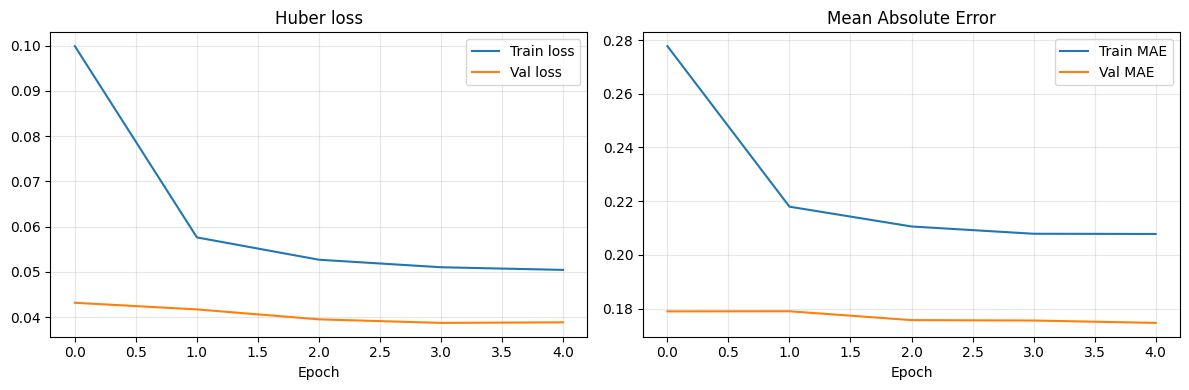

Training curves saved to training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="Train loss")
axes[0].plot(history.history["val_loss"], label="Val loss")
axes[0].set_title("Huber loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["mae"],     label="Train MAE")
axes[1].plot(history.history["val_mae"], label="Val MAE")
axes[1].set_title("Mean Absolute Error")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()
print("Training curves saved to training_curves.png")

## Evaluación

In [ ]:
print("\nEvaluating on test set...")
test_loss, test_mae = model.evaluate(test_dataset, verbose=1)
print(f"\nTest Huber loss : {test_loss:.4f}")
print(f"Test MAE        : {test_mae:.4f}")

# Naive baseline — always predict the training mean
# Your model must beat this to have learned something useful
naive_mae = float(np.abs(y_test - y_train.mean()).mean())
print(f"Naive baseline MAE (always predict train mean {y_train.mean():.3f}): {naive_mae:.4f}")

if test_mae < naive_mae:
    print(f"Model beats naive baseline by {naive_mae - test_mae:.4f} MAE points")
else:
    print("WARNING: model does not beat naive baseline — check training")


Evaluating on test set...
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 0.0388 - mae: 0.1747

Test Huber loss : 0.0388
Test MAE        : 0.1747
Naive baseline MAE (always predict train mean 0.096): 0.2992
Model beats naive baseline by 0.1246 MAE points


## Pre-bucket MAE - the honest evaluation

El MAE global es una métrica engañosa en datasets con distribución desigual: un modelo que prediga sistemáticamente valores cercanos a la media alcista obtendrá un error agregado aparentemente razonable sin haber aprendido nada útil sobre los extremos del espectro. Dado que el valor práctico del modelo reside precisamente en su capacidad de identificar correctamente artículos bajistas y fuertemente alcistas — las señales con mayor impacto en decisiones de inversión — el MAE global por sí solo no es suficiente para validar el modelo.

Esta evaluación desagrega el rendimiento en cinco rangos de puntuación para exponer dónde falla el modelo realmente. Se busca que el error sea homogéneo entre buckets: una diferencia pronunciada entre el MAE de *Bearish* y el de *Neutral* indicaría que el modelo está colapsando las predicciones hacia el centro de la distribución, es decir, que ha aprendido el sesgo alcista del dataset pero no la señal de los extremos. La comparación entre la media predicha y la media real por bucket permite además detectar sesgos sistemáticos de calibración — si el modelo predice consistentemente +0.1 cuando la media real del bucket *Bearish* es -0.6, el problema no es de varianza sino de sesgo estructural.

La precisión por bucket adyacente complementa la exacta: dado que las categorías son ordinales y sus fronteras son arbitrarias, confundir *Bearish* con *Somewhat-Bearish* es cualitativamente distinto a confundirlo con *Bullish*. Un modelo útil en producción debería errar, cuando lo haga, hacia la categoría vecina y no hacia el extremo opuesto.

In [ ]:
print("\nRunning predictions on test set...")
raw_preds = model.predict(test_dataset, verbose=1)
scores    = raw_preds.flatten()

def score_to_label(s):
    if s <= -0.35:             return "Bearish"
    if s <= -0.15:             return "Somewhat-Bearish"
    if s <   0.15:             return "Neutral"
    if s <   0.35:             return "Somewhat-Bullish"
    return "Bullish"

true_labels = np.array([score_to_label(s) for s in y_test])
pred_labels = np.array([score_to_label(s) for s in scores])

bucket_order = ["Bearish", "Somewhat-Bearish", "Neutral", "Somewhat-Bullish", "Bullish"]

print(f"\n{'Bucket':<22} {'N':>6}  {'MAE':>7}  {'Pred mean':>10}  {'True mean':>10}")
print("-" * 62)
for label in bucket_order:
    mask = true_labels == label
    if mask.sum() == 0:
        continue
    mae       = np.abs(y_test[mask] - scores[mask]).mean()
    pred_mean = scores[mask].mean()
    true_mean = y_test[mask].mean()
    print(f"{label:<22} {mask.sum():>6,}  {mae:>7.4f}  {pred_mean:>10.4f}  {true_mean:>10.4f}")

print(f"\n{'Overall':<22} {len(y_test):>6,}  {np.abs(y_test - scores).mean():>7.4f}")

# Label accuracy (derived from predicted float → bucket)
label_accuracy = (pred_labels == true_labels).mean()
print(f"\nBucket label accuracy : {label_accuracy:.1%}")

# Adjacent-bucket accuracy (allow one bucket off — e.g. Bearish predicted as Somewhat-Bearish)
def adjacent_correct(true, pred, order):
    ti = order.index(true)
    pi = order.index(pred)
    return abs(ti - pi) <= 1

adj_correct = sum(
    adjacent_correct(t, p, bucket_order)
    for t, p in zip(true_labels, pred_labels)
)
print(f"Adjacent-bucket accuracy (±1 bucket): {adj_correct / len(true_labels):.1%}")




Running predictions on test set...


109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step

Bucket                      N      MAE   Pred mean   True mean
--------------------------------------------------------------
Bearish                 1,123   0.2593     -0.2658     -0.5250
Somewhat-Bearish        1,353   0.1312     -0.1832     -0.2488
Neutral                 1,500   0.2008      0.0857      0.0414
Somewhat-Bullish        1,500   0.1463      0.2392      0.2675
Bullish                 1,500   0.1528      0.3258      0.4689

Overall                 6,976   0.1747

Bucket label accuracy : 43.0%
Adjacent-bucket accuracy (±1 bucket): 88.6%


## Guardamos el modelo y el tokenizer

In [ ]:
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

weights_path = os.path.join(MODEL_SAVE_DIR, "model_weights.weights.h5")
model.save_weights(weights_path)

tokenizer.save_pretrained(os.path.join(MODEL_SAVE_DIR, "tokenizer"))

print(f"Weights saved : {weights_path}")
print(f"Tokenizer saved : {MODEL_SAVE_DIR}/tokenizer/")

OSError: [Errno 107] Transport endpoint is not connected: '/content/gdrive/MyDrive'

In [ ]:
'''
# Save the full Keras model (architecture + weights + training config)
model.save(os.path.join(MODEL_SAVE_DIR, "saved_model.keras"))

# Save the tokenizer alongside the model
# Critical: at inference time you must use the same tokenizer
tokenizer.save_pretrained(os.path.join(MODEL_SAVE_DIR, "tokenizer"))

print(f"\nModel saved to  : {MODEL_SAVE_DIR}/model.keras")
print(f"Tokenizer saved : {MODEL_SAVE_DIR}/tokenizer/")
'''

'\n# Save the full Keras model (architecture + weights + training config)\nmodel.save(os.path.join(MODEL_SAVE_DIR, "saved_model.keras"))\n\n# Save the tokenizer alongside the model\n# Critical: at inference time you must use the same tokenizer\ntokenizer.save_pretrained(os.path.join(MODEL_SAVE_DIR, "tokenizer"))\n\nprint(f"\nModel saved to  : {MODEL_SAVE_DIR}/model.keras")\nprint(f"Tokenizer saved : {MODEL_SAVE_DIR}/tokenizer/")\n'

## Ejemplo de uso

In [ ]:
def predict_sentiment(texts, model, tokenizer, max_len=MAX_LEN, batch_size=32):
    """
    Predict sentiment scores for a list of raw text strings.

    Parameters
    ----------
    texts      : list of str — raw article texts (title + summary already combined,
                 or just titles, depending on how you trained)
    model      : loaded Keras model
    tokenizer  : matching HuggingFace tokenizer
    max_len    : must match MAX_LEN used during training
    batch_size : how many articles to encode at once

    Returns
    -------
    scores : np.ndarray of float, shape (N,), values in (-1, 1)
    labels : list of str, bucket label for each score
    """
    enc = tokenizer(
        list(texts),
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="tf"
    )

    dataset = tf.data.Dataset.from_tensor_slices({
        "input_ids":      enc["input_ids"],
        "attention_mask": enc["attention_mask"]
    }).batch(batch_size)

    raw = model.predict(dataset, verbose=0)
    scores = raw.flatten()
    labels = [score_to_label(s) for s in scores]
    return scores, labels


# --- Example usage ---
new_articles = [
    "Fed raises rates by 75bps [SEP] The Federal Reserve raised interest rates by 75 basis points, signalling further hikes ahead as inflation remains elevated above the 2% target.",
    "Markets surge on strong earnings [SEP] Wall Street posted its best week of the year as major tech companies reported blowout earnings, pushing the S&P 500 up 3.2% on the week.",
    "Oil prices steady amid supply concerns [SEP] Crude oil held near $85 per barrel as traders weighed OPEC output cuts against weaker demand signals from China.",
    "OPEC+ Makes Symbolic Oil Hike, Sees Long Supply Hit From War [SEP] OPEC+ warned that damage to Middle East energy assets will have a prolonged impact on oil supply even after the Iran war ends, as it approved a symbolic increase in output quotas for next month.",

]

pred_scores, pred_labels = predict_sentiment(new_articles, model, tokenizer)

print("\nInference results:")
print("-" * 70)
for text, score, label in zip(new_articles, pred_scores, pred_labels):
    short = text[:60] + "..." if len(text) > 60 else text
    print(f"Text   : {short}")
    print(f"Score  : {score:+.4f}   Label: {label}")
    print()


Inference results:
----------------------------------------------------------------------
Text   : Fed raises rates by 75bps [SEP] The Federal Reserve raised i...
Score  : +0.3291   Label: Somewhat-Bullish

Text   : Markets surge on strong earnings [SEP] Wall Street posted it...
Score  : +0.4371   Label: Bullish

Text   : Oil prices steady amid supply concerns [SEP] Crude oil held ...
Score  : +0.1162   Label: Neutral

Text   : OPEC+ Makes Symbolic Oil Hike, Sees Long Supply Hit From War...
Score  : +0.0046   Label: Neutral



In [ ]:
test = [
    "US inflation seen spiking in first snapshot since Iran war [SEP] Economists are penciling in a 1% increase in the consumer price index for March the sharpest one-month advance since 2022 after the Iran war pushed gas prices at the pump up by about $1 per gallon.",
    "Total market crash coming, stock sell off in Europe [SEP] The London stock exchanged open Monday with the worst sell off in the last 12 years, experts agree the crash will extend to other financial markets.",
    "Iran Has Threatened America's Tech Giants. Time to Sell? [SEP] These companies should take this threat seriously as the IRGC has already attacked some of Amazon's (NASDAQ: AMZN) data centers. Indeed, such attacks could slow the growth of tech companies, forcing them to either spend more to maintain operations or possibly leave the region altogether.",
    "Fed raises rates by 75bps [SEP] The Federal Reserve raised interest rates by 75 basis points, signalling further hikes ahead as inflation remains elevated above the 2% target.",
    "Markets surge on strong earnings [SEP] Wall Street posted its best week of the year as major tech companies reported blowout earnings, pushing the S&P 500 up 3.2% on the week.",
    "Oil prices steady amid supply concerns [SEP] Crude oil held near $85 per barrel as traders weighed OPEC output cuts against weaker demand signals from China.",
    "OPEC+ Makes Symbolic Oil Hike, Sees Long Supply Hit From War [SEP] OPEC+ warned that damage to Middle East energy assets will have a prolonged impact on oil supply even after the Iran war ends, as it approved a symbolic increase in output quotas for next month.",
]

pred_scores, pred_labels = predict_sentiment(test, model, tokenizer)

print("\nInference results:")
print("-" * 70)
for text, score, label in zip(test, pred_scores, pred_labels):
    print(f"Text   : {text}")
    print(f"Score  : {score:+.4f}   Label: {label}")
    print()


Inference results:
----------------------------------------------------------------------
Text   : US inflation seen spiking in first snapshot since Iran war [SEP] Economists are penciling in a 1% increase in the consumer price index for March the sharpest one-month advance since 2022 after the Iran war pushed gas prices at the pump up by about $1 per gallon.
Score  : +0.3151   Label: Somewhat-Bullish

Text   : Total market crash coming, stock sell off in Europe [SEP] The London stock exchanged open Monday with the worst sell off in the last 12 years, experts agree the crash will extend to other financial markets.
Score  : -0.2774   Label: Somewhat-Bearish

Text   : Iran Has Threatened America's Tech Giants. Time to Sell? [SEP] These companies should take this threat seriously as the IRGC has already attacked some of Amazon's (NASDAQ: AMZN) data centers. Indeed, such attacks could slow the growth of tech companies, forcing them to either spend more to maintain operations or possibly l

In [ ]:
from google.colab import drive
import shutil

# Mount Drive if not already mounted
drive.mount("/content/drive")

# Zip and copy directly to your Drive
shutil.make_archive("finbert_sentiment", "zip", "finbert_sentiment")
shutil.copy("finbert_sentiment.zip", "/content/drive/MyDrive/finbert_sentiment_v3.zip")

print("Saved to Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Google Drive


In [ ]:
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModel
import os

MODEL_SAVE_DIR = "finbert_sentiment"
MODEL_NAME     = "ProsusAI/finbert"
MAX_LEN        = 256
DROPOUT_RATE   = 0.2

# 1. Rebuild the architecture — must be identical to training
backbone = TFAutoModel.from_pretrained(MODEL_NAME)

model = FinBERTRegressor(backbone, dropout_rate=DROPOUT_RATE)

# Build by passing a dummy batch so layers are initialised
dummy = {
    "input_ids":      tf.zeros((1, MAX_LEN), dtype=tf.int32),
    "attention_mask": tf.zeros((1, MAX_LEN), dtype=tf.int32)
}
_ = model(dummy, training=False)

# 2. Load the saved weights into the rebuilt architecture
model.load_weights(os.path.join(MODEL_SAVE_DIR, "model_weights.weights.h5"))

# 3. Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(os.path.join(MODEL_SAVE_DIR, "tokenizer"))

print("Model and tokenizer loaded successfully")

# 4. Ready to use — inference works exactly as before
pred_scores, pred_labels = predict_sentiment(new_articles, model, tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.

All model checkpoint layers were used when initializing TFBertModel.

All the layers of TFBertModel were initialized from the model checkpoint at ProsusAI/finbert.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


Model and tokenizer loaded successfully
